In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
from collections import Counter
pd.set_option('display.max_columns', None)
import ast

In [67]:
import scipy.sparse as sp

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from sklearn.neighbors import NearestNeighbors


/Users/filimono/Documents/Coding/RecSys/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/movies_DB.csv')

In [3]:
drop_features = ['movie_id', 'title', 'poster_url', 'poster_urls', 'video_keys', 'external_ids']
embeddings_features = ['overview','tagline', 'review_texts']
tf_idf_features = ['genres', 'keywords', 'director', 'certification', 'cast']
num_features = ['release_date', 'runtime', 'popularity', 'budget', 'revenue']

# Числовые признаки

In [8]:
df.iloc[1]['genres']
[k.lower() for k in literal_eval(df.iloc[1]['genres'])]
' '.join([k.lower() for k in literal_eval(df.iloc[1]['genres'])])
df.iloc[1]['certification']

'PG'

## Tf-Idf

In [9]:
tf_idf_text = []

def data_to_tf_idf(df):
    for i in range(len(df)):
        parts = []
        
        genres = df.iloc[i]['genres']
        if pd.notna(genres):
            if isinstance(genres, str):
                genres = literal_eval(genres)
            clean_genres = [k.lower() for k in genres]
            parts.append(' '.join(clean_genres))
            
        keywords = df.iloc[i]['keywords']
        if pd.notna(keywords):
            if isinstance(keywords, str):
                keywords = literal_eval(keywords)
            clean_keywords = [k.lower().replace(' ', '_') for k in keywords]
            parts.append(' '.join(clean_keywords))
        
        
        director = df.iloc[i]['director']
        if pd.notna(director):
            clean_director = director.lower().replace(' ', '_')
            parts.append(clean_director)
            
        certification = df.iloc[i]['certification']
        if pd.notna(certification):
            clean_certification = certification.lower()
            parts.append(clean_certification)
            
        cast = df.iloc[i]['cast']
        if pd.notna(cast):
            if isinstance(cast, str):
                cast = ast.literal_eval(cast)
            
            clean_cast = []
            for actor in cast[:5]:  
                actor_name = actor['name'].lower().replace(' ', '_')
                clean_cast.append(actor_name)
            parts.append(' '.join(clean_cast))
        tf_idf_text.append(' '.join(parts))

    
    return tf_idf_text

In [10]:
tf_idf_text = data_to_tf_idf(df)

In [11]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2), min_df=2)
tfidf_matrix = tfidf.fit_transform(tf_idf_text)

In [12]:
tfidf_matrix.shape

(95501, 5000)

In [28]:
sp.save_npz('../data/model/tfidf_matrix.npz', tfidf_matrix)

In [13]:
tf_idf_features

['genres', 'keywords', 'director', 'certification', 'cast']

In [14]:
embeddings_features

['overview', 'tagline', 'review_texts']

In [15]:
df.iloc[1]['overview']

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures."

## Embeddings

In [16]:
emb_text = []

def data_to_emb(df):
    
    for i in range(len(df)):
        
        parts = []
        if pd.notna(df.iloc[i]['overview']):
            parts.append(str(df.iloc[i]['overview']))
            
        if pd.notna(df.iloc[i]['tagline']):
            parts.append(str(df.iloc[i]['tagline']))
            
        if pd.notna(df.iloc[i]['review_texts']):
            reviews = df.iloc[i]['review_texts']
            if isinstance(reviews, str):
                try:
                    reviews = ast.literal_eval(reviews)
                except:
                    reviews = []
            if isinstance(reviews, list):
                
                for review in reviews[:3]:
                    if review and isinstance(review, str):
                        parts.append(review.strip())
        
        emb_text.append(' '.join(parts))  
    
    return emb_text
    
    

In [17]:
emb_text = data_to_emb(df)

In [18]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7570.68it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
embeddings = model.encode(emb_text, batch_size=32, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

Batches: 100%|██████████| 2985/2985 [04:13<00:00, 11.76it/s]


In [20]:
embeddings_sparse = csr_matrix(embeddings)

In [21]:
embeddings_sparse.shape

(95501, 384)

In [27]:
sp.save_npz('../data/model/embeddings_sparse.npz', embeddings_sparse)

# Числовые предикаторы

In [22]:
num_features

['release_date', 'runtime', 'popularity', 'budget', 'revenue']

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95501 entries, 0 to 95500
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       95501 non-null  int64  
 1   title          95501 non-null  str    
 2   overview       94513 non-null  str    
 3   genres         95501 non-null  str    
 4   keywords       95501 non-null  str    
 5   director       94556 non-null  str    
 6   release_date   95467 non-null  str    
 7   runtime        95501 non-null  int64  
 8   popularity     95501 non-null  float64
 9   poster_url     94133 non-null  str    
 10  budget         95501 non-null  int64  
 11  revenue        95501 non-null  int64  
 12  tagline        44485 non-null  str    
 13  poster_urls    95501 non-null  str    
 14  video_keys     95501 non-null  str    
 15  review_texts   95501 non-null  str    
 16  external_ids   95501 non-null  str    
 17  certification  34800 non-null  str    
 18  cast           95

In [24]:
df['release_date']

0        1995-11-22
1        1995-12-15
2        1995-12-22
3        1995-12-22
4        1995-12-08
            ...    
95496    2025-02-13
95497    2025-05-17
95498    2025-06-09
95499    2025-03-21
95500    2025-10-28
Name: release_date, Length: 95501, dtype: str

In [40]:
df['year'] = df['release_date'].apply(lambda x: int(x.split('-')[0]) if isinstance(x, str) else 0)

In [4]:
df['runtime'].value_counts()

runtime
90     5118
95     2868
100    2763
93     2398
85     2343
       ... 
311       1
504       1
230       1
323       1
440       1
Name: count, Length: 337, dtype: int64

In [25]:
df.loc[72444, 'runtime'] = 1000

<Axes: ylabel='runtime'>

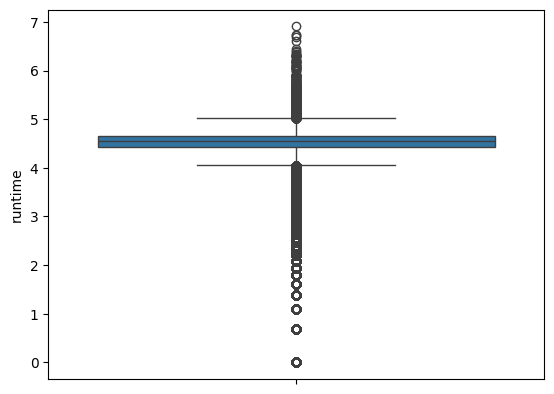

In [27]:
sns.boxplot(np.log1p(df['runtime']))

(0.0, 250.0)

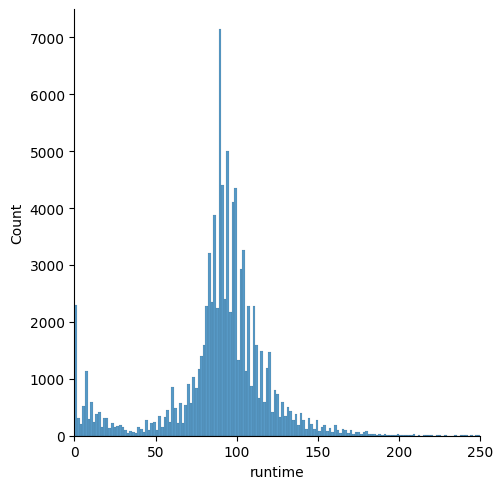

In [30]:
sns.displot(df['runtime'])
plt.xlim(0, 250)

In [33]:
df['popularity'].value_counts()

popularity
0.0143    242
0.0214    148
0.0071    145
0.0286    109
0.0000     96
         ... 
2.1088      1
1.9246      1
1.2084      1
0.6004      1
1.2442      1
Name: count, Length: 39349, dtype: int64

In [36]:
df[df['popularity'] > 300]

,movie_id,title,overview,genres,keywords,director,release_date,runtime,popularity,poster_url,budget,revenue,tagline,poster_urls,video_keys,review_texts,external_ids,certification,cast
91197,798645,The Running Man,"Desperate to save his sick daughter, working-c...","['Action', 'Thriller', 'Science Fiction']","['based on novel or book', 'dark comedy', 'sur...",Edgar Wright,2025-11-11,133,446.1148,https://image.tmdb.org/t/p/w500/dKL78O9zxczVgj...,110000000,68391082,Hunt him down.,['https://image.tmdb.org/t/p/w500/dKL78O9zxczV...,"['xMevjkItihw', 'Wp9P7EhSN5Q', 'VrUNH9pe1cY', ...",['FULL SPOILER-FREE REVIEW @ movieswetextedabo...,"{'id': 798645, 'imdb_id': 'tt14107334', 'wikid...",R,"[{'name': 'Glen Powell', 'profile_url': 'https..."
91198,1084242,Zootopia 2,After cracking the biggest case in Zootopia's ...,"['Animation', 'Comedy', 'Adventure', 'Family',...","['snake', 'bunny', 'fox', 'cop', 'sequel', 'an...",Jared Bush,2025-11-26,107,392.3259,https://image.tmdb.org/t/p/w500/oJ7g2CifqpStmo...,150000000,1137444817,Zootopia will be changed furrrever...,['https://image.tmdb.org/t/p/w500/ib6v6qUXzez1...,"['Op-5HjO5Txw', 'uKixOcSvvY8', '5H7L9j0dW90', ...",['FULL SPOILER-FREE REVIEW @ https://movieswet...,"{'id': 1084242, 'imdb_id': 'tt26443597', 'wiki...",PG,"[{'name': 'Ginnifer Goodwin', 'profile_url': '..."
91199,812583,Wake Up Dead Man: A Knives Out Mystery,When young priest Jud Duplenticy is sent to as...,"['Thriller', 'Mystery', 'Comedy']","['detective', 'investigation', 'sequel', 'murd...",Rian Johnson,2025-11-26,145,348.3879,https://image.tmdb.org/t/p/w500/qCOGGi8JBVEZMc...,210000000,4000000,He works in mysterious ways.,['https://image.tmdb.org/t/p/w500/qCOGGi8JBVEZ...,"['1FZFlZUj4tQ', '_r0Y1feGM24', 'zl7oD1Ot0fM', ...",['FULL SPOILER-FREE REVIEW @ https://fandomwir...,"{'id': 812583, 'imdb_id': 'tt14364480', 'wikid...",PG-13,"[{'name': 'Daniel Craig', 'profile_url': 'http..."


<Axes: ylabel='popularity'>

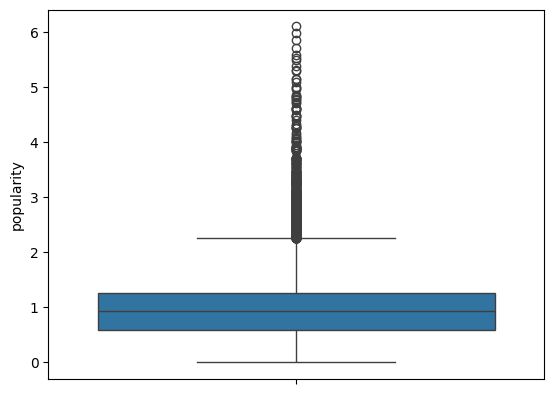

In [42]:
sns.boxplot(np.log1p(df['popularity']))

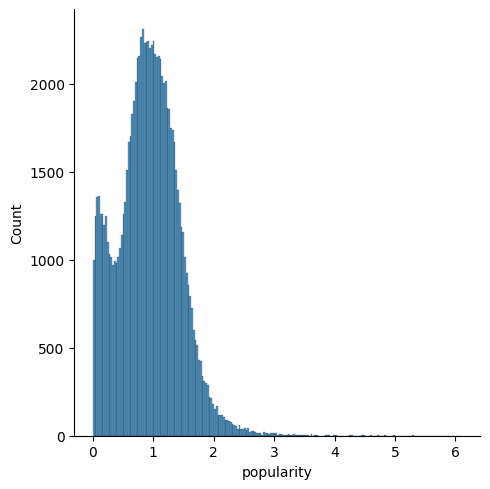

In [44]:
sns.displot(np.log1p(df['popularity']))

In [45]:
df['budget'].value_counts()

budget
0           78434
10000000      499
5000000       485
1000000       449
2000000       445
            ...  
1850            1
5400            1
668240          1
360             1
10673500        1
Name: count, Length: 2564, dtype: int64

In [46]:
78434 / 95501 * 100

82.12898294258699

<Axes: ylabel='budget'>

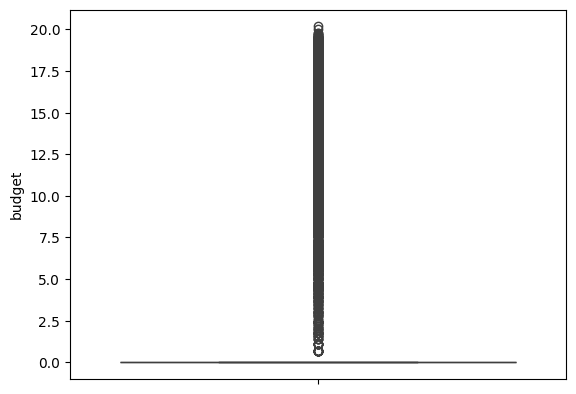

In [48]:
sns.boxplot(np.log1p(df['budget']))

In [49]:
df['revenue'].value_counts()

revenue
0           78928
2000000        54
10000000       50
5000000        44
1000000        44
            ...  
1068            1
58558           1
215586          1
77433           1
379705          1
Name: count, Length: 14210, dtype: int64

In [54]:
num_features

['runtime', 'popularity', 'budget', 'revenue', 'year']

In [55]:
df_num = df[num_features].copy()

In [58]:

df_num['popularity'] = np.log1p(df_num['popularity']) 
df_num['budget'] =  np.log1p(df_num['budget']) 
df_num['revenue']=  np.log1p(df_num['revenue']) 

In [60]:
scaler = StandardScaler()

In [62]:
df_num.info()

<class 'pandas.DataFrame'>
RangeIndex: 95501 entries, 0 to 95500
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   runtime     95501 non-null  int64  
 1   popularity  95501 non-null  float64
 2   budget      95501 non-null  float64
 3   revenue     95501 non-null  float64
 4   year        95501 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 3.6 MB


In [63]:
num_normalized = scaler.fit_transform(df_num)

In [64]:
num_sparse = csr_matrix(num_normalized)

In [65]:
num_sparse.shape

(95501, 5)

In [68]:
sp.save_npz('../data/model/num_sparse.npz', num_sparse)